<a href="https://colab.research.google.com/github/Ibrahim-Hidayat/CodeAlpha_Unemployment_Analysis/blob/main/Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Unemployment in India.csv")
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [10]:
df.columns = df.columns.str.strip()
df = df.dropna(how="all")

for col in ["Region", "Date", "Frequency", "Area"]:
    df[col] = df[col].str.strip()

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "LabourParticipation",
})

print(df.shape)
print(df.isna().sum())

(740, 7)
Region                 0
Date                   0
Frequency              0
Unemployment           0
Employed               0
LabourParticipation    0
Area                   0
dtype: int64


In [11]:
df.info()
df.describe()
df.groupby("Region")["Unemployment"].mean().sort_values(ascending=False).round(2)

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Region               740 non-null    object        
 1   Date                 740 non-null    datetime64[ns]
 2   Frequency            740 non-null    object        
 3   Unemployment         740 non-null    float64       
 4   Employed             740 non-null    float64       
 5   LabourParticipation  740 non-null    float64       
 6   Area                 740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


,Unemployment
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


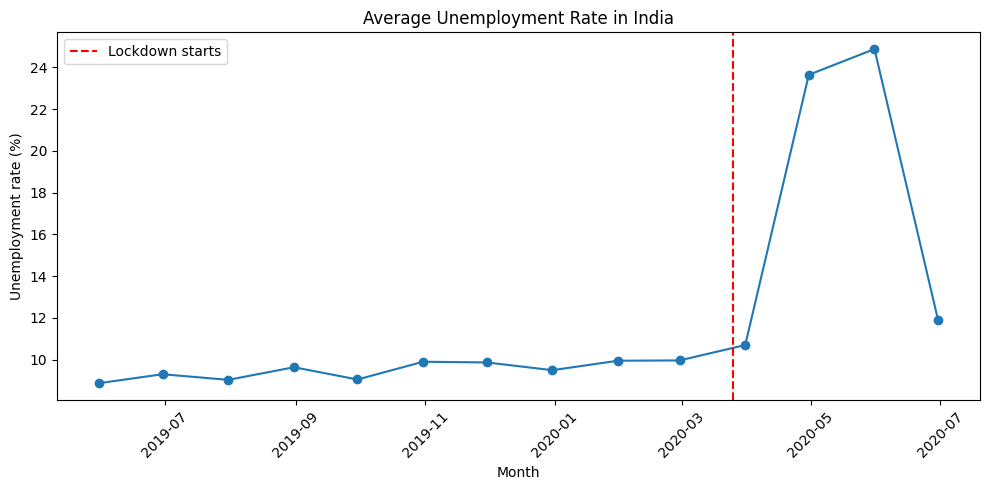

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
monthly = df.groupby("Date")["Unemployment"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.axvline(pd.to_datetime("2020-03-25"), color="red", linestyle="--", label="Lockdown starts")
plt.title("Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Unemployment rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("unemployment_trend.png", dpi=200)
plt.show()

from google.colab import files
files.download("unemployment_trend.png")

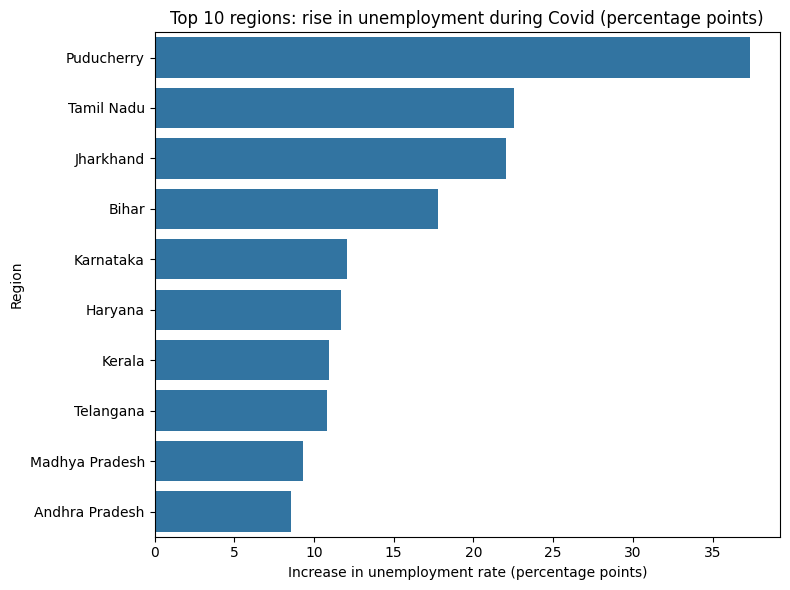

Period,Covid,Pre-Covid,Change
Region,,,
Puducherry,38.96,1.59,37.36
Tamil Nadu,25.40,2.84,22.57
Jharkhand,36.35,14.28,22.07
Bihar,31.63,13.83,17.80
Karnataka,15.28,3.23,12.05
Haryana,34.65,22.94,11.72
Kerala,17.95,6.99,10.96
Telangana,15.44,4.66,10.79
Madhya Pradesh,14.07,4.74,9.33


In [13]:
df["Period"] = df["Date"].apply(lambda d: "Pre-Covid" if d < pd.to_datetime("2020-03-01") else "Covid")

cmp = df.groupby(["Region", "Period"])["Unemployment"].mean().unstack()
cmp["Change"] = cmp["Covid"] - cmp["Pre-Covid"]
cmp = cmp.sort_values("Change", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=cmp.reset_index().head(10), x="Change", y="Region")
plt.title("Top 10 regions: rise in unemployment during Covid (percentage points)")
plt.xlabel("Increase in unemployment rate (percentage points)")
plt.tight_layout()
plt.savefig("covid_impact_by_region.png", dpi=200)
plt.show()

cmp.round(2).head(10)

In [14]:
files.download("covid_impact_by_region.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>